# 1. Retrieve connectivity (example olfaction)

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import random
import pyreadr
import networkx as nx
from neuprint import Client
from neuprint import fetch_roi_hierarchy
from neuprint import NeuronCriteria as NC, SynapseCriteria as SC
from neuprint import fetch_neurons, fetch_synapses,fetch_adjacencies, fetch_traced_adjacencies
TOKEN ="YOUR TOKEN"
c = Client('neuprint.janelia.org', 'hemibrain:v1.2.1', TOKEN)

In [ ]:
neuron_criteria_ORN = NC(status='Traced', type='ORN.*', regex=True, outputRois='AL(R)', min_roi_outputs=0, min_pre=0)
neuron_df_ORN, conn_df_ORN = fetch_neurons(neuron_criteria_ORN)
l0=[]
for i,x in enumerate(neuron_df_ORN["outputRois"]):
    if "AL(L)" in x:
        l0.append(i)
neuron_df_ORN=neuron_df_ORN.drop(l0)

neuron_criteria_LN = NC(status='Traced', cropped=False, type='.*LN.*', regex=True, inputRois='AL(R)', outputRois='AL(R)', min_roi_inputs=0, min_pre=0)
neuron_df_LN, conn_df_LN = fetch_neurons(neuron_criteria_LN)

neuron_criteria_PN = NC(status='Traced', cropped=False, type='.*PN',  regex=True, inputRois='AL(R)', outputRois='CA(R)', min_roi_inputs=0, min_pre=0)
neuron_df_PN, conn_df_PN = fetch_neurons(neuron_criteria_PN)


      bodyId      instance    type  pre   post  downstream  upstream  mito  \
0  300972942  MBON14(a3)_R  MBON14  543  13634        4336     13634   283   

         size  status  cropped     statusLabel cellBodyFiber somaRadius  \
0  1566415099  Traced    False  Roughly traced          None       None   

  somaLocation                                            roiInfo notes  \
0         None  {'MB(R)': {'pre': 17, 'post': 13295, 'downstre...  None   

                                           inputRois  \
0  [MB(+ACA)(R), MB(R), SIP(R), SLP(R), SMP(R), S...   

                                          outputRois  
0  [MB(+ACA)(R), MB(R), SIP(R), SLP(R), SMP(R), S...  
      bodyId      instance    type  pre   post  downstream  upstream  mito  \
0  733036127  MBON07(a1)_R  MBON07  474  15519        4710     15519   400   

         size  status  cropped     statusLabel cellBodyFiber  somaRadius  \
0  1520161953  Traced    False  Roughly traced         ADM10       292.5   

        

In [ ]:
print('ORN:%d LN:%d PN:%d' %(len(neuron_df_ORN), len(neuron_df_LN), len(neuron_df_PN)))

Nid=pd.concat([neuron_df_ORN['bodyId'], neuron_df_LN['bodyId']], axis=0)
Nid=pd.concat([Nid, neuron_df_PN['bodyId']], axis=0)
print(len(Nid))
df = pd.DataFrame(index=Nid, columns=Nid)
df=df.fillna(0)

ORN:1780 LN:191 PN:121 KC:1919 APL:1 MBONa3:1 MBONa1:1 SMP:1
4015


In [ ]:
neuron_df, conn_df = fetch_adjacencies(neuron_df_ORN["bodyId"], neuron_df_PN["bodyId"], min_roi_weight=10) 
for column_name, item in conn_df.iterrows():
    df[item['bodyId_pre']][item['bodyId_post']]=1

neuron_df, conn_df = fetch_adjacencies(neuron_df_PN["bodyId"], neuron_df_PN["bodyId"],min_roi_weight=10) 
for column_name, item in conn_df.iterrows():
    df[item['bodyId_pre']][item['bodyId_post']]=1


ORN_type=neuron_df_ORN[['bodyId','type']]

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
# THis big cell is specific to olfaction, no need for 


# LN coupling data with statistic data from Seki2010
Nid_LN0=[] 
Nid_LN1=[]
Nid_LN2=[]
Nid_LN3=[]
crate=1
random.seed(0)
for i,x in enumerate(neuron_df_LN["bodyId"]):
    if i<len(neuron_df_LN["bodyId"])/4:
        Nid_LN0.append(x)
    elif(i<len(neuron_df_LN["bodyId"])/4*2):
        Nid_LN1.append(x)
    elif(i<len(neuron_df_LN["bodyId"])/4*3):
        Nid_LN2.append(x)
    else:
        Nid_LN3.append(x)
print(len(Nid_LN0),len(Nid_LN1),len(Nid_LN2),len(Nid_LN3))

for i,x in enumerate(Nid_LN0):
    c0=0
    for j,y in enumerate(neuron_df_ORN["bodyId"]):
        t0=ORN_type[ORN_type["bodyId"].isin([y])]["type"].tolist()
        t0=t0[0]
        if t0=="ORN_DM5" or t0=="ORN_VA7m":
            if random.random()<0.8*crate:
                df[y][x]=1
                c0+=1
        else:
            if random.random()<1*crate:
                df[y][x]=1
                c0+=1
    for j,y in enumerate(neuron_df_LN["bodyId"]):
        if random.random()<1*crate:
            df[y][x]=1
            df[x][y]=1
            c0+=1
    for j,y in enumerate(neuron_df_PN[["bodyId","type"]].values.tolist()):
        if "DM5" in y[1] or "VA7m" in y[1]:
            if random.random()<0.8*crate:
                df[y[0]][x]=1
                df[x][y[0]]=1
                c0+=1
        else:
            if random.random()<1*crate:
                df[y[0]][x]=1
                df[x][y[0]]=1
                c0+=1
    print(i,c0)
for i,x in enumerate(Nid_LN1):
    c0=0
    for j,y in enumerate(neuron_df_ORN["bodyId"]):
        t0=ORN_type[ORN_type["bodyId"].isin([y])]["type"].tolist()
        t0=t0[0]
        if "DA3" in t0 or "DA4m" in t0 or "DC1" in t0 or "DA4l" in t0 or "DL3" in t0 or "ORN_V" == t0 or "DA2" in t0 or "VA5" in t0 or "ORN_D" == t0 or "DC4" in t0 or "VM4" in t0 or "VM1" in t0 or "VM6" in t0:
            ;
        elif "DL1" in t0:    
            if random.random()<2.0/6*crate:
                df[y][x]=1
                c0+=1
        elif "DM4" in t0:    
            if random.random()<1.0/6*crate:
                df[y][x]=1
                c0+=1
        elif "DL4" in t0:    
            if random.random()<4.0/6*crate:
                df[y][x]=1
                c0+=1
        elif "VC1" in t0:    
            if random.random()<5.0/6*crate:
                df[y][x]=1
                c0+=1
        else:
            if random.random()<1*crate:
                df[y][x]=1
                c0+=1
    for j,y in enumerate(neuron_df_LN["bodyId"]):
        if random.random()<1*crate:
            df[y][x]=1
            df[x][y]=1
            c0+=1
    for j,y in enumerate(neuron_df_PN[["bodyId","type"]].values.tolist()):
        t0=y[1]
        y=y[0]
        if "DA3" in t0 or "DA4m" in t0 or "DC1" in t0 or "DA4l" in t0 or "DL3" in t0 or "V C PN" == t0 or "DA2" in t0 or "VA5" in t0 or "D adPN" == t0 or "DC4" in t0 or "VM4" in t0 or "VM1" in t0 or "VM6" in t0:
            ;
        elif "DL1" in t0:    
            if random.random()<2.0/6*crate:
                df[y][x]=1
                df[x][y]=1
                c0+=1
        elif "DM4" in t0:    
            if random.random()<1.0/6*crate:
                df[y][x]=1
                df[x][y]=1
                c0+=1
        elif "DL4" in t0:    
            if random.random()<4.0/6*crate:
                df[y][x]=1
                df[x][y]=1
                c0+=1
        elif "VC1" in t0:    
            if random.random()<5.0/6*crate:
                df[y][x]=1
                df[x][y]=1
                c0+=1
        else:
            if random.random()<1*crate:
                df[y][x]=1
                df[x][y]=1
                c0+=1
    print(i,c0)
for i,x in enumerate(Nid_LN2):
    c0=0
    for j,y in enumerate(neuron_df_ORN["bodyId"]):
        t0=ORN_type[ORN_type["bodyId"].isin([y])]["type"].tolist()
        t0=t0[0]
        if "DA1" in t0 or "DL4" in t0 or "DA2" in t0: 
            if random.random()<2.0/8*crate:
                df[y][x]=1
                c0+=1
        elif "DA3" in t0 or "DC3" in t0 or "VA7m" in t0: 
            if random.random()<1.0/8*crate:
                df[y][x]=1
                c0+=1            
        elif "VA1d" in t0 or "VM2" in t0: 
            if random.random()<3.0/8*crate:
                df[y][x]=1
                c0+=1            
        elif "DL3" in t0: 
            if random.random()<7.0/8*crate:
                df[y][x]=1
                c0+=1                
        else:
            if random.random()<1*crate:
                df[y][x]=1
                c0+=1
    for j,y in enumerate(neuron_df_LN["bodyId"]):
        if random.random()<1*crate:
            df[y][x]=1
            df[x][y]=1
            c0+=1
    for j,y in enumerate(neuron_df_PN[["bodyId","type"]].values.tolist()):
        t0=y[1]
        y=y[0]
        if "DA1" in t0 or "DL4" in t0 or "DA2" in t0: 
            if random.random()<2.0/8*crate:
                df[y][x]=1
                df[x][y]=1
                c0+=1
        elif "DA3" in t0 or "DC3" in t0 or "VA7m" in t0: 
            if random.random()<1.0/8*crate:
                df[y][x]=1
                df[x][y]=1
                c0+=1            
        elif "VA1d" in t0 or "VM2" in t0: 
            if random.random()<3.0/8*crate:
                df[y][x]=1
                df[x][y]=1
                c0+=1            
        elif "DL3" in t0: 
            if random.random()<7.0/8*crate:
                df[y][x]=1
                df[x][y]=1
                c0+=1                
        else:
            if random.random()<1*crate:
                df[y][x]=1
                df[x][y]=1
                c0+=1
    print(i,c0)
for i,x in enumerate(Nid_LN3):
    c0=0
    for j,y in enumerate(neuron_df_ORN["bodyId"]):
        t0=ORN_type[ORN_type["bodyId"].isin([y])]["type"].tolist()
        t0=t0[0]
        if "DA1" in t0 or "VA1m" in t0 or "VM6" in t0: 
            if random.random()<5.0/6*crate:
                df[y][x]=1
                c0+=1
        elif "VA1d": 
            if random.random()<4.0/6*crate:
                df[y][x]=1
                c0+=1               
        elif "DL3" in t0: 
            if random.random()<3.0/6*crate:
                df[y][x]=1
                c0+=1                
        else:
            if random.random()<1*crate:
                df[y][x]=1
                df[x][y]=1
                c0+=1
    for j,y in enumerate(neuron_df_LN["bodyId"]):
        if random.random()<1*crate:
            df[y][x]=1
            df[x][y]=1
            c0+=1
    for j,y in enumerate(neuron_df_PN[["bodyId","type"]].values.tolist()):
        t0=y[1]
        y=y[0]
        if "DA1" in t0 or "VA1m" in t0 or "VM6" in t0: 
            if random.random()<5.0/6*crate:
                df[y][x]=1
                df[x][y]=1
                c0+=1
        elif "VA1d": 
            if random.random()<4.0/6*crate:
                df[y][x]=1
                df[x][y]=1
                c0+=1               
        elif "DL3" in t0: 
            if random.random()<3.0/6*crate:
                df[y][x]=1
                df[x][y]=1
                c0+=1                
        else:
            if random.random()<1*crate:
                df[y][x]=1
                df[x][y]=1
                c0+=1
    print(i,c0)
    

48 48 48 47
0 2084
1 2083
2 2085
3 2085
4 2086
5 2081
6 2082
7 2079
8 2085
9 2079
10 2087
11 2077
12 2083
13 2087
14 2084
15 2082
16 2086
17 2080
18 2084
19 2083
20 2081
21 2079
22 2081
23 2082
24 2082
25 2077
26 2083
27 2078
28 2085
29 2082
30 2080
31 2081
32 2085
33 2085
34 2081
35 2083
36 2081
37 2080
38 2085
39 2081
40 2090
41 2082
42 2083
43 2083
44 2083
45 2082
46 2087
47 2082
0 1726
1 1721
2 1726
3 1735
4 1719
5 1734
6 1725
7 1728
8 1725
9 1724
10 1721
11 1728
12 1721
13 1723
14 1721
15 1722
16 1720
17 1717
18 1721
19 1725
20 1728
21 1723
22 1724
23 1724
24 1729
25 1721
26 1724
27 1723
28 1718
29 1727
30 1727
31 1729
32 1717
33 1721
34 1723
35 1720
36 1725
37 1719
38 1718
39 1727
40 1722
41 1724
42 1727
43 1726
44 1729
45 1732
46 1729
47 1721
0 1823
1 1814
2 1831
3 1825
4 1809
5 1817
6 1835
7 1835
8 1812
9 1817
10 1835
11 1830
12 1823
13 1837
14 1842
15 1823
16 1818
17 1822
18 1829
19 1843
20 1815
21 1828
22 1811
23 1822
24 1811
25 1827
26 1819
27 1818
28 1827
29 1834
30 1835
31

In [10]:

def create_coe_file(path,ndf_pre,ndf_post,divide_num,divide_len):
    l0=[]
    for x in ndf_pre:
        l0.append(x)   
    for k in range(divide_num):
        l1=[]
        for i, x in enumerate(ndf_post):
            if i>=k*divide_len and i< (k+1)*divide_len:
                l1.append(x)
        path0=path+"_"+str(k)+".coe"
        with open(path0, mode='w') as f:
            f.write("memory_initialization_radix = 2;\n")
            f.write("memory_initialization_vector =\n")
            c0=0
            c1=0
            a=np.zeros([len(l1),len(l0)])
            for i,iid in enumerate(l1):
                for j,jid in enumerate(l0):
                    if df[jid][iid]==1:
                        c1+=1
                        f.write("1,\n")
                        a[i,j]=1
                    else:
                        f.write("0,\n")
                    c0=c0+1
        plt.figure(figsize=(10, 10))
        plt.imshow(a)
        plt.show()
        print(path0,str(c0)+"="+str(len(l0))+"*"+str(len(l1)),c1)




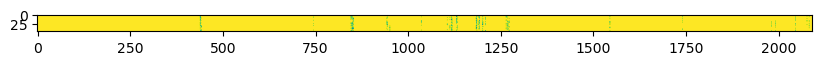

coe_0.coe 94140=2092*45 93715


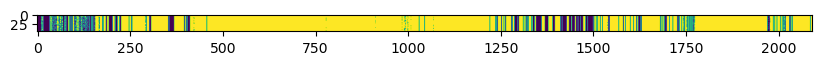

coe_1.coe 94140=2092*45 78646


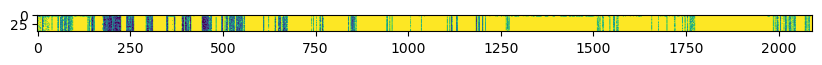

coe_2.coe 94140=2092*45 81536


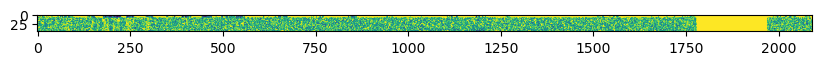

coe_3.coe 94140=2092*45 69497


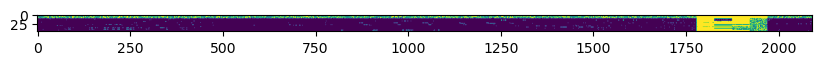

coe_4.coe 94140=2092*45 22273


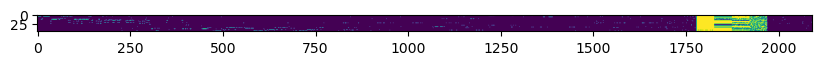

coe_5.coe 94140=2092*45 7966


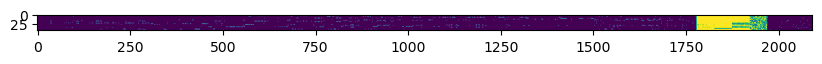

coe_6.coe 87864=2092*42 8379


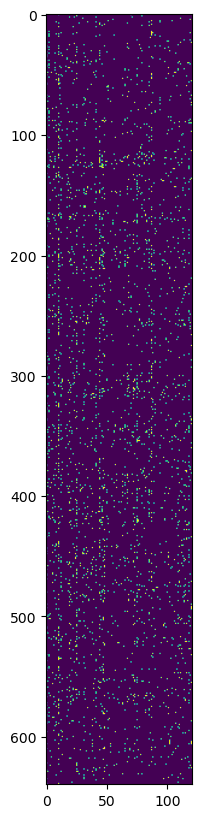

coe_0.coe 77440=121*640 2914


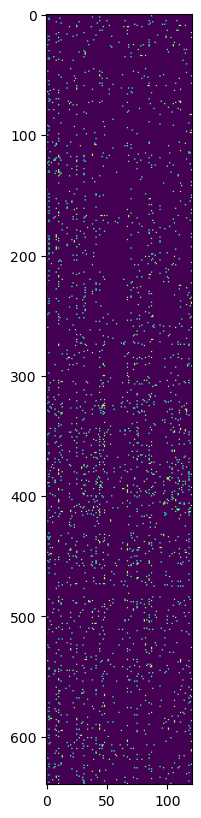

coe_1.coe 77440=121*640 2431


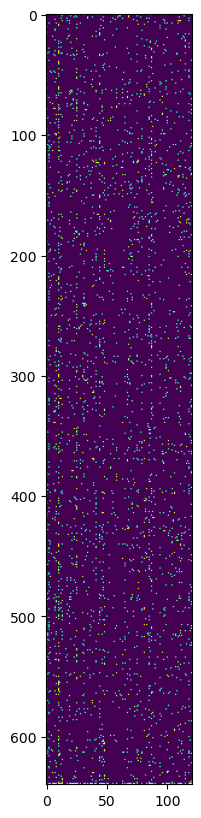

coe_2.coe 77440=121*640 2905


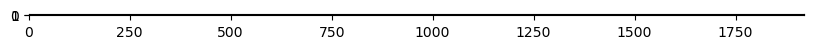

coe_0.coe 3838=1919*2 2527


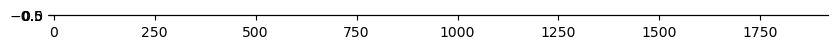

coe_0.coe 1919=1919*1 734


In [ ]:
create_coe_file('coe',pd.concat([neuron_df_ORN['bodyId'],neuron_df_LN['bodyId'],neuron_df_PN['bodyId']]),pd.concat([neuron_df_LN['bodyId'], neuron_df_PN['bodyId']]),7,45)

neuron_df_ORN.to_csv('neuron_df_ORN.csv')

neuron_df_LN.to_csv('neuron_df_LN.csv')

neuron_df_PN.to_csv('neuron_df_PN.csv')


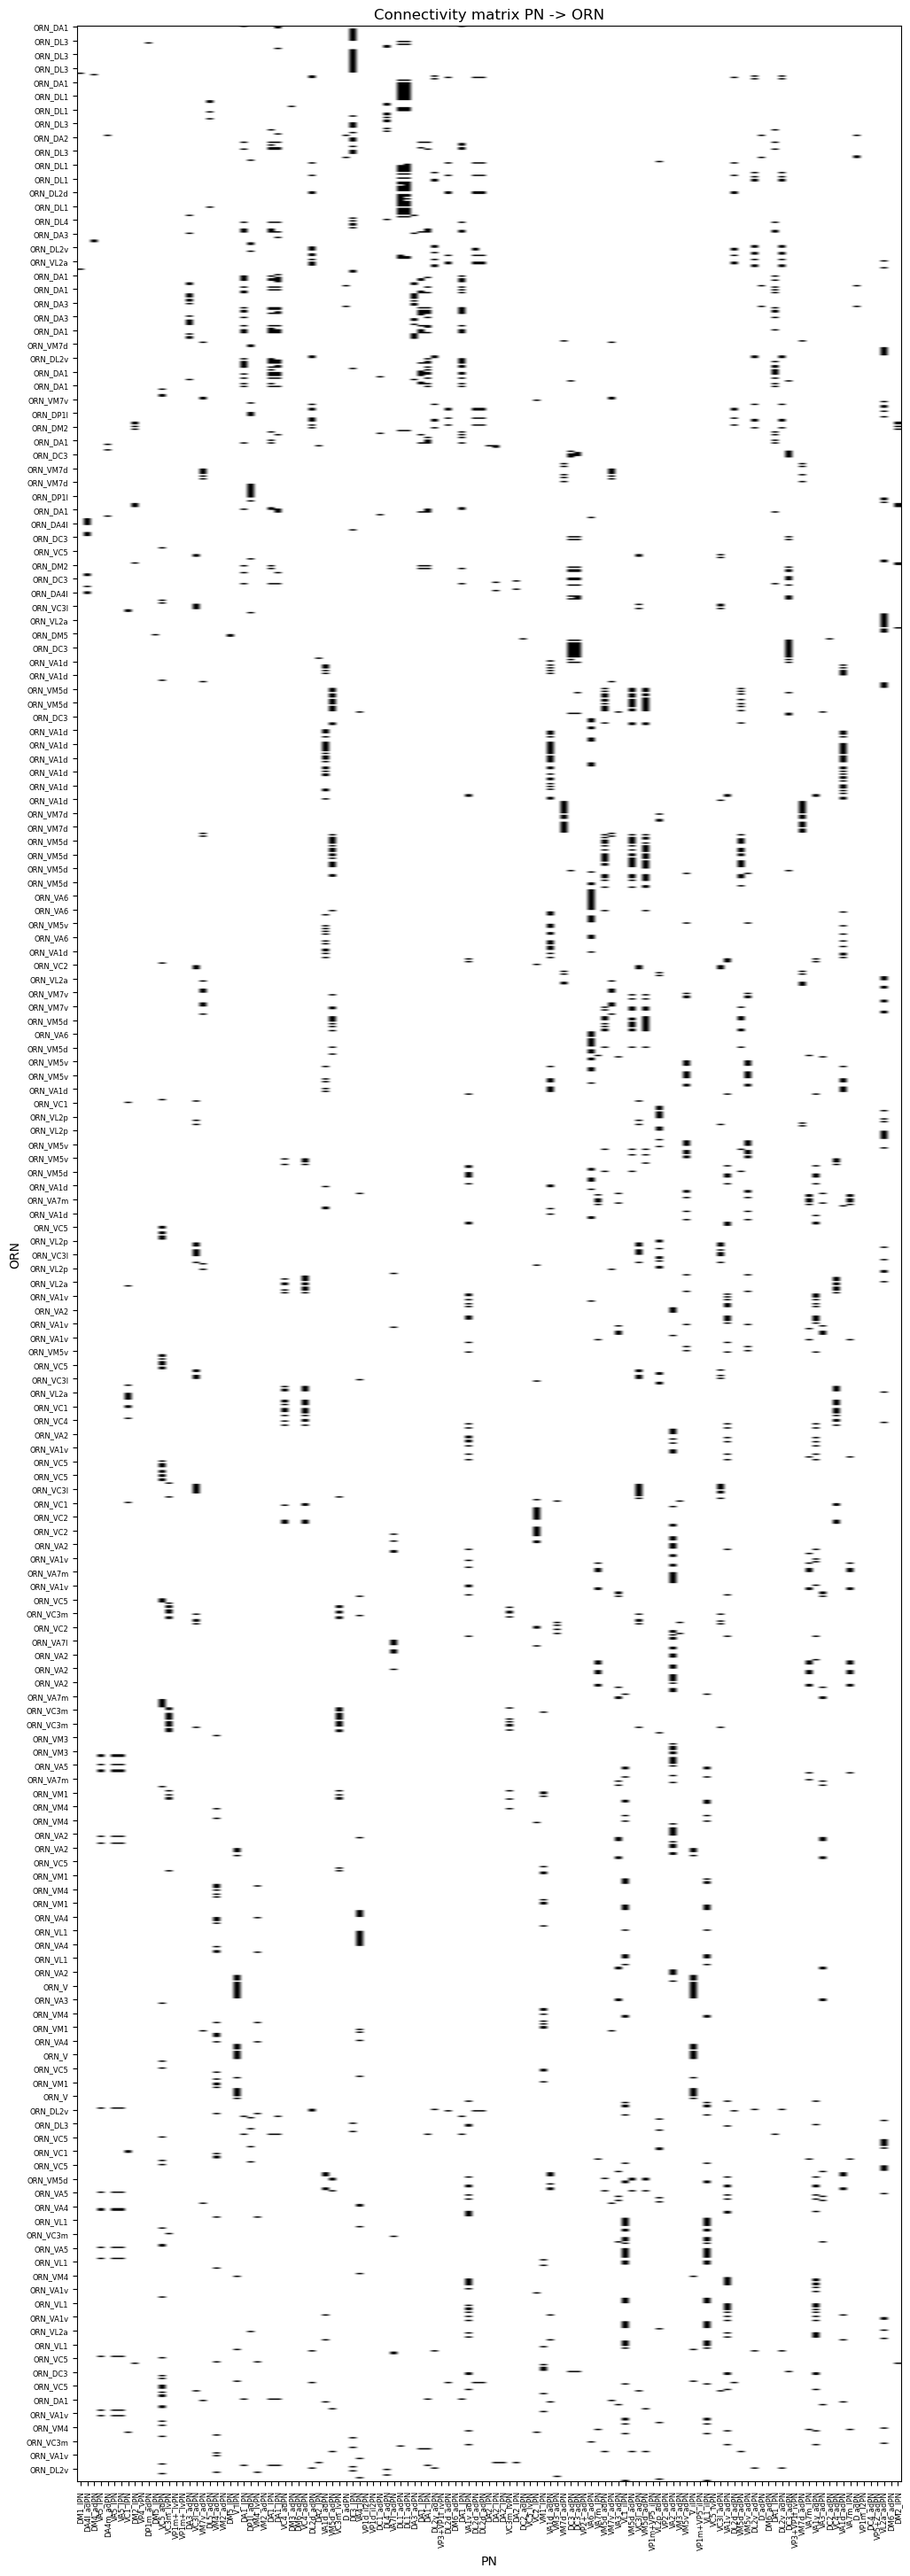

In [ ]:
#don't run cells above if file exist juste do pd.read_csv...

pre=neuron_df_ORN['bodyId']
post=neuron_df_PN['bodyId']

df = pd.DataFrame(index=post, columns=pre)
df = df.fillna(0)  # Initialiser toutes les valeurs à 0

#  connexions existantes
neuron_df, conn_df = fetch_adjacencies(neuron_df_ORN["bodyId"], neuron_df_PN["bodyId"], min_roi_weight=10)
for _, item in conn_df.iterrows():
    df.loc[item['bodyId_post'], item['bodyId_pre']] = 1



plt.figure(figsize=(12, 36))
plt.imshow(df.T, cmap='binary', aspect='auto')


k=10
yticks_positions = np.arange(0, len(neuron_df_ORN['type']), k)
yticks_labels = [neuron_df_ORN['type'].iloc[i] for i in yticks_positions]
plt.yticks(yticks_positions, yticks_labels, fontsize=6)

plt.xticks(np.arange(len(neuron_df_PN['bodyId'])), neuron_df_PN['type'], rotation=90, fontsize=6)

plt.xlabel('PN')
plt.ylabel('ORN')
plt.title('Connectivity matrix PN -> ORN')

plt.show()

In [ ]:
df = pd.DataFrame(np.random.randint(0, 2, size=(len(neuron_df_PN), len(neuron_df_ORN))),
                  index=neuron_df_PN['bodyId'],
                  columns=neuron_df_ORN['bodyId'])

types_ORN = sorted(neuron_df_ORN['type'].unique())
types_PN = sorted(neuron_df_PN['type'].unique())

connectivity_matrix_by_type = pd.DataFrame(0, index=types_PN, columns=types_ORN)

for orn_type in types_ORN:
    for pn_type in types_PN:
        orn_body_ids = neuron_df_ORN[neuron_df_ORN['type'] == orn_type]['bodyId']
        pn_body_ids = neuron_df_PN[neuron_df_PN['type'] == pn_type]['bodyId']

        connectivity_matrix_by_type.loc[pn_type, orn_type] = df.loc[pn_body_ids, orn_body_ids].values.mean()

plt.figure(figsize=(12, 10))
plt.imshow(connectivity_matrix_by_type, cmap='binary', aspect='auto')

plt.xticks(np.arange(len(types_ORN)), types_ORN, rotation=90, fontsize=8)
plt.yticks(np.arange(len(types_PN)), types_PN, fontsize=8)

plt.xlabel('ORN Types (Colonnes)')
plt.ylabel('PN Types (Lignes)')
plt.title('Matrice de Connectivité entre Types ORN et PN')

plt.colorbar(label='Connectivité Moyenne')
plt.tight_layout()
plt.show()

# 2. Make a spiking neural network with pytorch